In [2]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [3]:
to_primitive_array = lambda x: [ float(i) for i in x]

## Первичная обработка данных

### Загрузка датасета

In [12]:
data = np.loadtxt('variant_8.csv', delimiter=',')

print(f"Объём выборки: n = {len(data)}")

Объём выборки: n = 100


### Сортировка данных

In [5]:
sorted_data = sorted(data)

# Выведите первые 5 и последние 5 значений вариационного ряда
print("Первые 5 элементов", to_primitive_array(sorted_data[:5]))
print("Последние 5 элементов", to_primitive_array(sorted_data[-5:]))

Первые 5 элементов [49.4, 58.6, 60.8, 64.1, 65.1]
Последние 5 элементов [105.3, 105.4, 105.5, 105.6, 108.0]


### Выборочные оценки

In [ ]:
x_bar = (1/(len(sorted_data)))*sum(sorted_data)                                          # среднее
s2 =  (1/(len(sorted_data)-1))*sum([abs(elem - x_bar)**2 for elem in sorted_data])       # дисперсия (несмещённая!)
s = np.sqrt(s2)                                                                          # стандартное отклонение
median = (sorted_data[len(sorted_data)//2] + sorted_data[len(sorted_data)//2 + 1] )/2    # медиана
x_min = np.min(sorted_data)                                                              # минимум
x_max = np.max(sorted_data)                                                              # максимум

print("Выборочные оценки:")
print(f"  Среднее:      x̄ = {x_bar:.2f}")
print(f"  Дисперсия:    s² =  {s2:.2f}")
print(f"  Ст. откл.:    s =  {s:.2f}")
print(f"  Медиана:      x̃ =  {median:.2f}")
print(f"  Размах:       [{x_min:.1f}, {x_max:.1f}]")

Выборочные оценки:
  Среднее:      x̄ = 84.75
  Дисперсия:    s² =  119.71
  Ст. откл.:    s =  10.94
  Медиана:      x̃ =  85.30
  Размах:       [49.4, 108.0]


### Правило Скотта

In [14]:
n = len(data)
h = 3.5 * s * n**(-1/3)
k = np.ceil((x_max - x_min)/h)  # число интервалов (округлить вверх)

print(f"Правило Скотта:")
print(f"  Ширина интервала: h = {h:.2f}")
print(f"  Число интервалов: k = {k}")

Правило Скотта:
  Ширина интервала: h = 8.25
  Число интервалов: k = 8.0


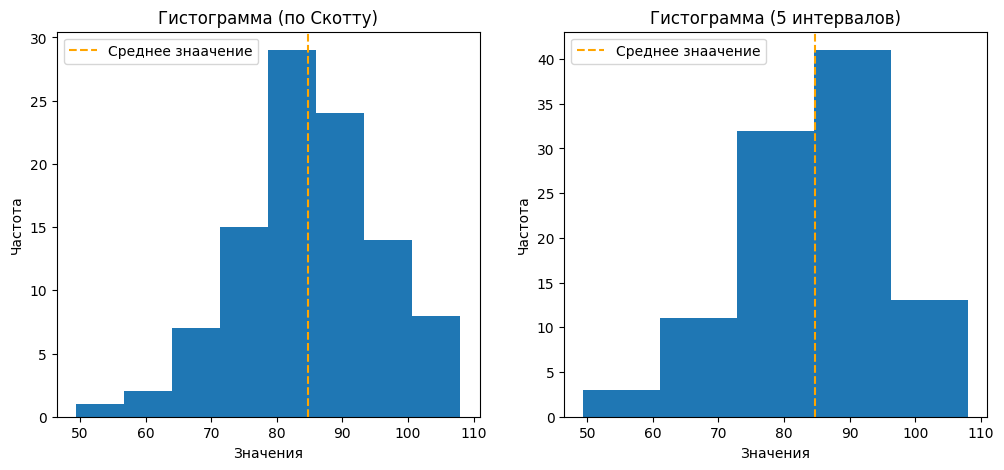

In [15]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(sorted_data, bins=int(k))
plt.axvline(x_bar, linestyle='--', color="orange", label="Среднее знаачение")
plt.title("Гистограмма (по Скотту)")
plt.xlabel("Значения")
plt.ylabel("Частота")
plt.legend()

plt.subplot(1,2,2)
plt.hist(sorted_data, bins=5)
plt.axvline(x_bar, linestyle='--', color="orange", label="Среднее знаачение")
plt.title("Гистограмма (5 интервалов)")
plt.xlabel("Значения")
plt.ylabel("Частота")
plt.legend()

plt.show()

### Полигон частот

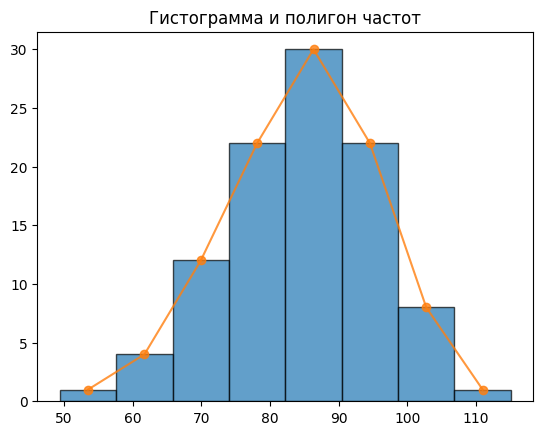

In [9]:
primitive_k = int(k)

bins = [x_min + h*i for i in range(primitive_k + 1)]

# Частоты
freq = Counter(map(
    lambda x: ((x-x_min)/h+1)//1,
    sorted_data
)).values()

# Середины интервалов
midpoints = [(bins[i] + bins[i+1]) / 2 for i in range(primitive_k)]

plt.hist(data, bins=bins, alpha=0.7, edgecolor='black')  # колонки
plt.plot(midpoints, freq, marker='o', alpha=0.8)         # линия поверх
plt.title("Гистограмма и полигон частот")
plt.show()

###  Эмпирическая функция распределения

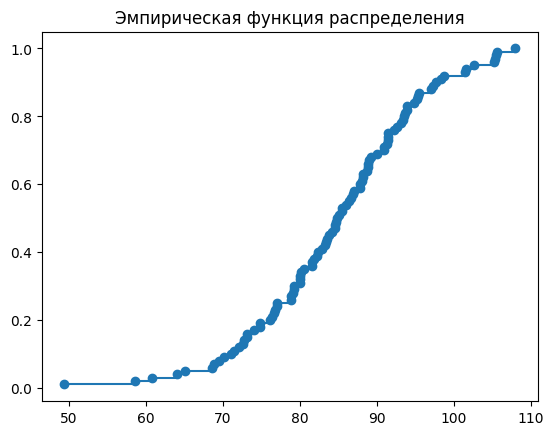

In [10]:
F = [(i+1)/n for i in range(n)]
    

plt.step(sorted_data, F, where='post')
plt.scatter(sorted_data, F)
plt.title("Эмпирическая функция распределения")
plt.show()


### Сравнение с истинными параметрами

In [11]:
mu_true = 85         # впишите своё значение μ
sigma2_true = 144    # впишите своё значение σ²

print("Сравнение с истинными параметрами:")
print(f"  Истинное μ = {mu_true}, выборочное x̄ = {x_bar:.4f}")
print(f"  Истинное σ² = {sigma2_true}, выборочное s² = {s2:.4f}")
print()
print("Ответ на вопрос:")
print("Выборочные оценки отличаются от истинных параметров,")
print("потому что выборка конечна и содержит случайные отклонения.")
print("При увеличении объёма выборки оценки сходятся к истинным значениям (закон больших чисел).")

Сравнение с истинными параметрами:
  Истинное μ = 85, выборочное x̄ = 84.7510
  Истинное σ² = 144, выборочное s² = 118.5085

Ответ на вопрос:
Выборочные оценки отличаются от истинных параметров,
потому что выборка конечна и содержит случайные отклонения.
При увеличении объёма выборки оценки сходятся к истинным значениям (закон больших чисел).
